# Retail Store Sales Analysis (Core)

*Part V: Advanced Data Exploration and Visualization*

---

Author: heleneInsights

Development Date: 16-05-2026

---

## Objective

In this fifth part of the project, we will expand our exploratory data analysis (EDA) and visualization skills using more advanced techniques. We will apply everything we have learned so far, including grids, legends, annotations, arrows, and subplots, to gain a deeper understanding of our retail sales dataset.

---

## Dataset Description

In this project, we will use the Retail Sales Dataset (2023–2024) available on Kaggle. This dataset contains detailed records of daily sales transactions from a retail store, including information such as products, quantities sold, prices, and dates.

The dataset can be downloaded from Kaggle:
https://www.kaggle.com/datasets/mohammadtalib786/retail-sales-dataset

---

## Data Dictionary

The table below describes the variables included in the retail sales dataset used throughout this project.

| Column Name        | Data Type       | Description                                                  | Example                             |
| ------------------ | --------------- | ------------------------------------------------------------ | ----------------------------------- |
| `transaction_id`   | Integer         | Unique identifier for each sales transaction                 | `1`                                 |
| `date`             | Date            | Date when the transaction took place                         | `2023-11-24`                        |
| `customer_id`      | String          | Unique identifier assigned to each customer                  | `CUST001`                           |
| `gender`           | Categorical     | Gender of the customer                                       | `Male`, `Female`                    |
| `age`              | Integer         | Age of the customer                                          | `34`                                |
| `product_category` | Categorical     | Category of the purchased product                            | `Beauty`, `Clothing`, `Electronics` |
| `quantity`         | Integer         | Number of units purchased in the transaction                 | `3`                                 |
| `price_per_unit`   | Float / Integer | Price of a single unit of the product                        | `50`                                |
| `total_amount`     | Float / Integer | Total value of the transaction (`quantity × price_per_unit`) | `150`                               |

---

## Setup

### Configuration and Imports

We start by importing the required libraries for data analysis and visualization.

In [56]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

### Dataset Availability and Path Setup

We define the data directory and verify that the required dataset file is available before loading it.

In [58]:
data_dir = Path("../data")

# List available files (for verification)
available_files = list(data_dir.iterdir())
print("Available files:", available_files)
file_name = "retail_sales_dataset.csv"
dataset_path = data_dir / file_name

Available files: [WindowsPath('../data/retail_sales_dataset.csv')]


In [59]:
# Validate dataset existence
if not dataset_path.exists():
    raise FileNotFoundError(f"{file_name} not found in {data_dir}")

print("Dataset found at:", dataset_path)

Dataset found at: ..\data\retail_sales_dataset.csv


### Data Loading

The dataset is loaded into a Pandas DataFrame from the CSV file.

In [60]:
df = pd.read_csv(dataset_path)

To get an initial understanding of the dataset structure, we display the first 10 rows.

In [61]:
df.head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200


This initial inspection helps verify that the dataset was loaded correctly and provides a quick understanding of the available information.

### Verify Structure

We check the shape of the dataset to understand how many rows and columns it contains.

In [62]:
print(f"{file_name}")
print(f"Shape: {df.shape}")
print(f"→ {df.shape[0]} rows, {df.shape[1]} columns\n")

retail_sales_dataset.csv
Shape: (1000, 9)
→ 1000 rows, 9 columns



### First and Last Records

We review the first and last rows of the dataset to verify that the data is consistent and correctly loaded.

In [63]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [64]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


---

## Exploratory Data Analysis

### Dataset Overview

The dataset contains 1,000 rows and 9 columns of transactional and customer-related information, including purchase details, customer demographics, and pricing data.

An initial inspection of the dataset provides insights into:

- Total number of rows and columns
- Column names
- Data types
- Non-null values
- Overall dataset structure

From the output of `df.info()`, we observe that all columns contain complete data, with no missing values detected. However, the `Date` column is currently stored as a string (`object`/`str`) rather than a proper datetime format. This will be corrected during the data cleaning and preprocessing stage to enable accurate time-based analysis.

The dataset consists of:

- 5 integer (`int64`) columns
- 4 string (`object`) columns

Additionally, the dataset uses approximately 70.4 KB of memory.

In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


### Summary Statistics

The summary statistics provide an overview of the numerical variables in the dataset, including measures such as the mean, standard deviation, minimum, maximum, and quartile values.

In [66]:
df.describe().round(2)

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.00,1000.00,1000.00,1000.00,1000.0
mean,500.50,41.39,2.51,179.89,456.0
std,288.82,13.68,1.13,189.68,560.0
min,1.00,18.00,1.00,25.00,25.0
25%,250.75,29.00,1.00,30.00,60.0
50%,500.50,42.00,3.00,50.00,135.0
75%,750.25,53.00,4.00,300.00,900.0
max,1000.00,64.00,4.00,500.00,2000.0


**Key Observations**

- The average customer age is approximately **41 years**.
- Customers purchase an average of **2.5 products per transaction**.
- The average price per unit is around **180**, while the average total transaction value is **456**.
- Customer ages range from **18 to 64 years**.
- The maximum transaction value recorded is **2000**.

These statistics help describe the overall distribution of the data and provide useful insights before performing further analysis or visualization.

### Missing Values

No missing values were detected in the dataset. This simplifies the data cleaning process and ensures that all records contain complete information.

In [67]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

### Duplicate Records

We use `df.duplicated().sum()` to check for exact duplicate rows in the dataset.

In [68]:
n_duplicated = df.duplicated().sum()
print(f"Exact duplicated rows before cleaning: {n_duplicated}")

Exact duplicated rows before cleaning: 0


The result shows that there are **no duplicated records** in the dataset. This means each row represents a unique transaction, and no duplicate removal is required.

### Distribution Analysis

#### Categorical Value Consistency

This analysis examines the distribution and frequency of values across all dataset columns to identify patterns, inconsistencies, and potential data quality issues.

In [69]:
for col in df.columns:
    print(f"\n{'='*40}")
    print(f"Column: {col}")
    print(f"{'='*40}")

    summary = (
        df[col]
        .value_counts(dropna=False)
        .reset_index()
    )

    summary.columns = [col, 'Count']

    summary['Percentage'] = (
        summary['Count'] / len(df) * 100
    ).round(2)

    print(summary)


Column: Transaction ID
     Transaction ID  Count  Percentage
0                 1      1         0.1
1                 2      1         0.1
2                 3      1         0.1
3                 4      1         0.1
4                 5      1         0.1
..              ...    ...         ...
995             996      1         0.1
996             997      1         0.1
997             998      1         0.1
998             999      1         0.1
999            1000      1         0.1

[1000 rows x 3 columns]

Column: Date
           Date  Count  Percentage
0    2023-05-16     11         1.1
1    2023-07-14     10         1.0
2    2023-05-23      9         0.9
3    2023-08-05      8         0.8
4    2023-02-05      8         0.8
..          ...    ...         ...
340  2023-03-02      1         0.1
341  2023-08-02      1         0.1
342  2023-04-17      1         0.1
343  2023-03-30      1         0.1
344  2023-05-28      1         0.1

[345 rows x 3 columns]

Column: Customer ID
    

**Key Findings**

- Both `Transaction ID` and `Customer ID` contain unique values for each record, confirming there are no duplicate transactions or repeated customer identifiers.
- The `Gender` distribution is fairly balanced, with **51% Female** and **49% Male** customers.
- Customer ages are well distributed between **18 and 64 years**, with no obvious outliers or invalid values.
- The Product Category distribution shows:
    - **Clothing** as the most frequent category (35.1%),
    - followed by **Electronics** (34.2%),
    - and **Beauty** (30.7%).
- Product quantities are evenly distributed between **1 and 4 units per transaction**.
- The `Price per Unit` column contains a small set of predefined values, suggesting a standardized pricing structure.
- The `Total Amount` column shows repeated values, which is expected since it is derived from combinations of quantity and unit price.

Overall, the dataset appears consistent, structured, and free from obvious categorical anomalies.

#### Outlier Detection

Boxplots are used to visually inspect numerical variables for potential outliers and unusual data distributions.

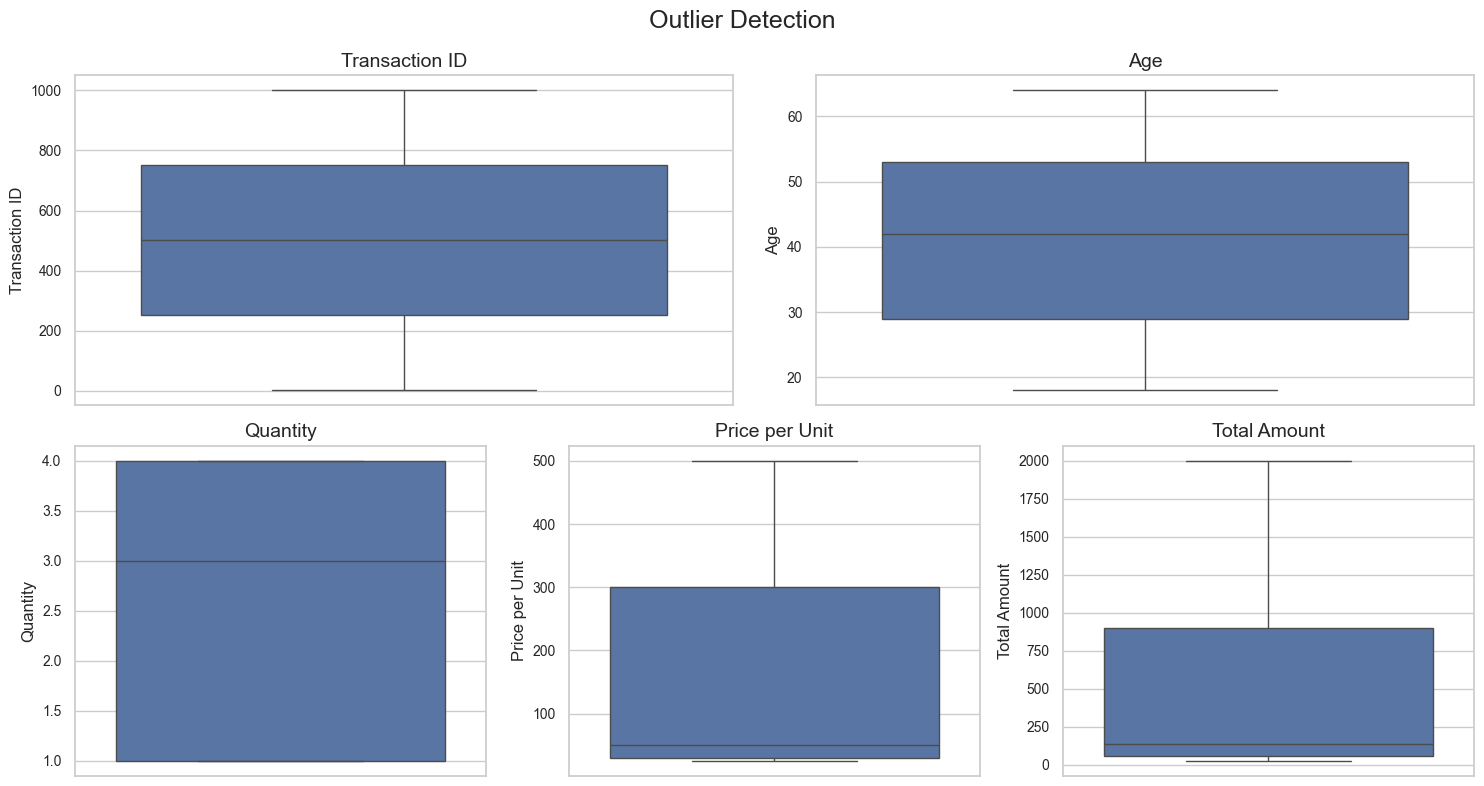

In [70]:
# Numerical columns
num_cols = [
    'Transaction ID',
    'Age',
    'Quantity',
    'Price per Unit',
    'Total Amount'
]

# Create figure
fig = plt.figure(figsize=(15, 8))

# Global title
fig.suptitle('Outlier Detection', fontsize=18)

# Create custom grid
gs = fig.add_gridspec(2, 6)

# First row (2 plots)
ax1 = fig.add_subplot(gs[0, 0:3])
ax2 = fig.add_subplot(gs[0, 3:6])

# Second row (3 plots)
ax3 = fig.add_subplot(gs[1, 0:2])
ax4 = fig.add_subplot(gs[1, 2:4])
ax5 = fig.add_subplot(gs[1, 4:6])

axes = [ax1, ax2, ax3, ax4, ax5]

# Plot boxplots
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

**Key Findings**

- `Age` values are well distributed within the expected range, with no significant outliers detected.
- `Quantity` is limited to a small range (1 to 4), which explains the absence of extreme values.
- `Price per Unit` and `Total Amount` show wider distributions due to variations in product pricing and transaction sizes; however, these values remain consistent with the business context of the dataset.
- `Transaction ID` does not contain meaningful outliers, as it is a sequential identifier rather than a numerical measure of behavior.

Overall, the boxplots do not reveal any critical anomalies or extreme outliers. The numerical data appears clean and suitable for further analysis.

#### Histograms

Histograms are used to visualize the distribution of numerical variables in the dataset. They help us understand frequency patterns, spread, and the concentration of values.

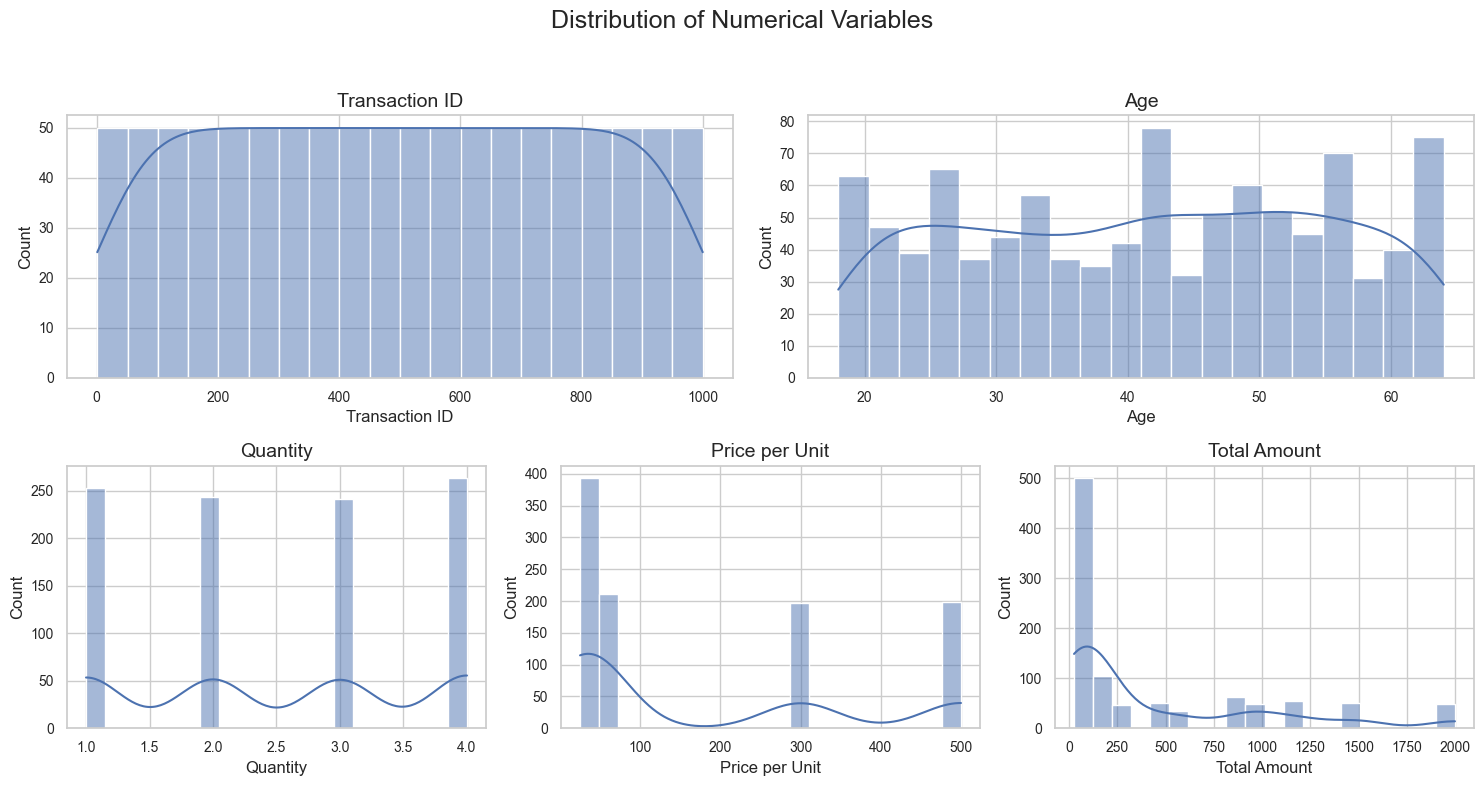

In [71]:
# Create figure
fig = plt.figure(figsize=(15, 8))

# Global title
fig.suptitle('Distribution of Numerical Variables', fontsize=18)

# Create custom grid
gs = fig.add_gridspec(2, 6)

# First row
ax1 = fig.add_subplot(gs[0, 0:3])
ax2 = fig.add_subplot(gs[0, 3:6])

# Second row
ax3 = fig.add_subplot(gs[1, 0:2])
ax4 = fig.add_subplot(gs[1, 2:4])
ax5 = fig.add_subplot(gs[1, 4:6])

axes = [ax1, ax2, ax3, ax4, ax5]

# Plot histograms
for ax, col in zip(axes, num_cols):
    sns.histplot(
        data=df,
        x=col,
        bins=20,
        kde=True,
        ax=ax
    )

    ax.set_title(col)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

**Key Observations**
- `Transaction ID` shows a uniform distribution, as identifiers are sequential and not related to behavior.
- `Age` is fairly evenly distributed across the observed range, with no strong skewness or clustering.
- `Quantity` consists of a small set of discrete values (1 to 4), resulting in clearly separated bars.
- `Price per Unit` shows grouped price levels, suggesting a standardized pricing structure for products.
- `Total Amount` is right-skewed, with most transactions concentrated at lower values and fewer high-value purchases.

The KDE (Kernel Density Estimation) curves provide additional insight into the overall shape of each distribution, making it easier to identify trends, skewness, and concentration patterns in the data.

Overall, the dataset shows a mix of discrete business constraints (quantity, pricing tiers) and continuous customer behavior (age, spending patterns).

### Transaction Validation

This step verifies that the `Total Amount` column has been correctly calculated for all transactions.

$$
\text{Total Amount} = \text{Quantity} \times \text{Price per Unit}
$$

In [72]:
(df['Quantity'] * df['Price per Unit'] == df['Total Amount']).all()

np.True_

**Observation**

All transaction totals are consistent with the corresponding quantity and unit price values. This confirms that the Total Amount column is correctly computed and that the dataset maintains strong internal consistency.

This validation confirms that no manual entry or calculation errors are present in the derived revenue field.

---

## Data Cleaning

During the initial assessment, it was identified that the `Date` column was stored as a string (`object`) instead of a proper datetime format.

To correct this, the column was converted to `datetime` using `pd.to_datetime()`.

In [73]:
df_clean = df.copy()

In [74]:
df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce")
df_clean["Date"].isna().sum()

np.int64(0)

The parameter `errors="coerce"` ensures that any invalid date values are converted into `NaT` (Not a Time), making problematic records easier to detect and handle during data cleaning.

**Observation**

After conversion, no invalid date values were detected. This confirms that the `Date` column was successfully transformed into a proper datetime format, and the dataset is now ready for time-based analysis.

This conversion enables grouping and resampling operations for temporal analysis.

### Invalid Datetime Check

In [75]:
df_clean[df_clean["Date"].isna()]

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount


This check is performed to identify any rows with invalid or missing datetime values after conversion.

Since no rows are returned, no invalid date values were found in the dataset.

### Data Type Comparison

**Before cleaning:**

In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


**After cleaning:**

In [77]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB


The comparison between the original and cleaned DataFrames confirms that the `Date` column was successfully converted from `object` (string) to `datetime64[ns]`.

Note on Datetime Precision

It is observed that the converted `Date` column appears as `datetime64[us]` (microsecond precision) instead of the more commonly seen `datetime64[ns]` (nanosecond precision). This difference is only related to internal storage precision in pandas and does not affect the accuracy or usability of the data for analysis. Both formats are functionally equivalent for time-based operations used in this project.

**Observation**

The conversion improves the dataset structure and enables time-based analysis, such as:

- Monthly or yearly aggregation
- Trend analysis over time
- Date-based filtering and grouping

This transformation is essential for analyzing sales trends over time, which will be explored in the next section.

### Updated Descriptive Statistics

After the data cleaning process, descriptive statistics were reviewed again to verify the consistency of the numerical columns and ensure that the dataset remained valid after the transformations.

In [78]:
df_clean.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


**Key Observations**

- The summary statistics remain consistent with the original dataset after cleaning, indicating that no data was lost or altered incorrectly during transformation.
- Numerical variables such as `Age`, `Quantity`, `Price per Unit`, and `Total Amount` maintain stable distributions.
- The `Date` column is now properly interpreted as a datetime field, which allows for time-based analysis.
- The presence of `NaN` in the standard deviation for Date is expected, as standard deviation is not meaningful for datetime values.

This confirms that the cleaning process only affected data types and not the underlying values.

### Cleaned Dataset Preview

In [79]:
df_clean.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


The cleaned dataset was reviewed to confirm that all transformations were applied correctly and that the overall structure remains consisten

**Insight**

Converting columns to appropriate data types improves data consistency and enables more efficient filtering, grouping, and time-based analysis.

It also prepares the dataset for visualization and future stages such as predictive modeling.

The dataset is now fully prepared for exploratory visualization and deeper analytical insights.

---

## Exploring Relationships and Correlations in Sales Data

### Correlation Matrix

To understand relationships between numerical variables, we compute the correlation matrix for key features in the dataset.

In [80]:
corr_cols = ['Total Amount', 'Quantity', 'Price per Unit', 'Age']

corr_matrix = df_clean[corr_cols].corr()
corr_matrix

,Total Amount,Quantity,Price per Unit,Age
Total Amount,1.000000,0.373707,0.851925,-0.060568
Quantity,0.373707,1.000000,0.017501,-0.023737
Price per Unit,0.851925,0.017501,1.000000,-0.038423
Age,-0.060568,-0.023737,-0.038423,1.000000


### Correlation Heatmap

We visualize the relationships between variables using a heatmap.

To improve readability, only the lower triangle of the correlation matrix is displayed using a mask. Since correlation matrices are symmetric (the relationship between A and B is the same as B and A), hiding the upper triangle removes redundant information and makes the visualization cleaner and easier to interpret.

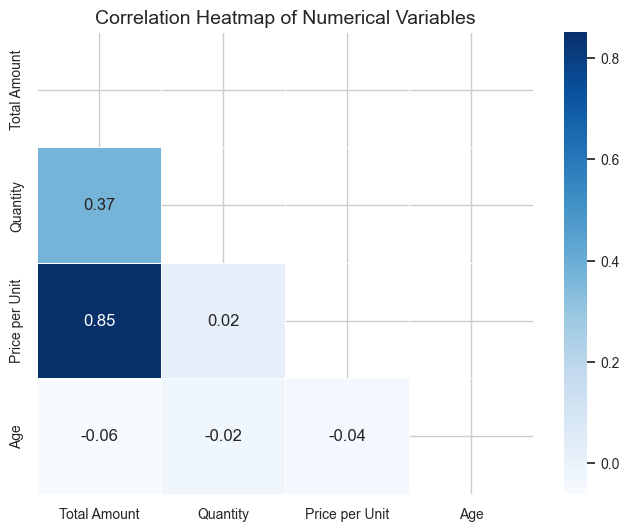

In [81]:
mask = np.triu(np.ones_like(corr_matrix, dtype = bool))

plt.figure(figsize = (8, 6))
sns.heatmap(
    corr_matrix,
    annot = True,
    cmap = "Blues",
    fmt = ".2f",
    linewidths = 0.5,
    mask = mask
)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

**Key Insights**

- There is a **strong positive correlation (0.85)** between `Price per Unit` and `Total Amount`, indicating that higher unit prices significantly increase total transaction value.
- `Quantity` also shows a **moderate positive correlation (0.37)** with `Total Amount`, meaning larger purchases tend to increase overall spending.
- `Age` has **very weak or near-zero correlation** with all other variables, suggesting that customer age does not strongly influence purchasing behavior in this dataset.
- `Price per Unit` and `Quantity` are almost uncorrelated (0.02), indicating that pricing does not significantly affect the number of items purchased per transaction.

Overall, the correlation analysis shows that **transaction value is primarily driven by price and quantity, while demographic factors such as age have minimal impact.**

---

## Key Business Insights Through Data Visualization

### Retail Sales Dashboard

The last month was excluded from the visualization as it contained only two transactions, which could distort the trend interpretation.

In [82]:
df_2024 = df_clean[df_clean["Date"].dt.year == 2024]
df_2024

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
210,211,2024-01-01,CUST211,Male,42,Beauty,3,500,1500
649,650,2024-01-01,CUST650,Male,55,Electronics,1,30,30


To validate the structure of the dataset, a filtered analysis was performed for the year 2024. This allows us to confirm the distribution of transactions in the most recent year without modifying the original dataset.

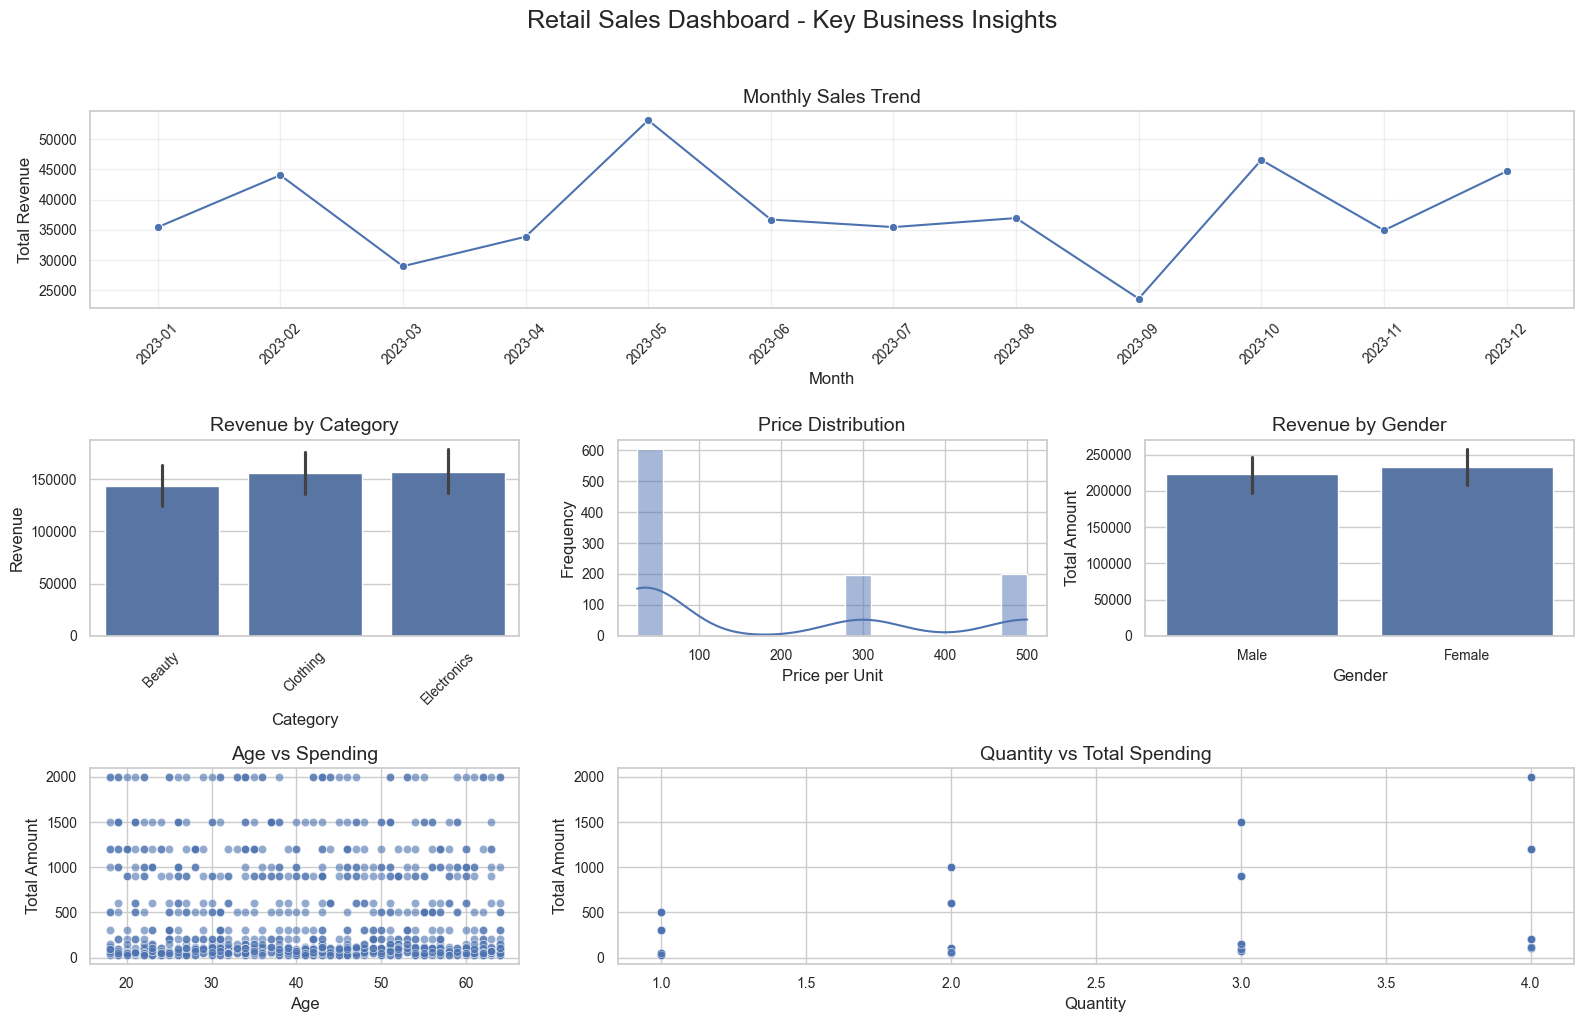

In [83]:
fig = plt.figure(figsize = (16, 10))
fig.suptitle("Retail Sales Dashboard - Key Business Insights", fontsize = 18, y = 1.02)

gs = fig.add_gridspec(3, 3)

# ------------------------
# 1. Monthly Sales Trend (top row, full width)
# ------------------------
ax1 = fig.add_subplot(gs[0, :])

monthly = df_clean.groupby(df_clean["Date"].dt.to_period("M"))["Total Amount"].sum().reset_index()
monthly["Date"] = monthly["Date"].astype(str)

monthly = monthly.iloc[:-1] # Until December 2023

sns.lineplot(
    data = monthly, 
    x = "Date", 
    y = "Total Amount", 
    marker = "o", 
    ax = ax1
    )
ax1.set_title("Monthly Sales Trend")
ax1.set_xlabel("Month") 
ax1.set_ylabel("Total Revenue")
ax1.tick_params(axis = 'x', rotation = 45)
ax1.grid(True, alpha = 0.3)

# ------------------------
# 2. Revenue by Category
# ------------------------
ax2 = fig.add_subplot(gs[1, 0])

sns.barplot(
    data = df_clean,
    x = "Product Category",
    y = "Total Amount",
    estimator = sum,
    ax = ax2
)
ax2.set_title("Revenue by Category")
ax2.set_xlabel("Category") 
ax2.set_ylabel("Revenue")
ax2.tick_params(axis='x', rotation=45)

# ------------------------
# 3. Price Distribution
# ------------------------
ax3 = fig.add_subplot(gs[1, 1])

sns.histplot(df_clean["Price per Unit"], bins=15, kde=True, ax=ax3)
ax3.set_title("Price Distribution")
ax3.set_xlabel("Price per Unit") 
ax3.set_ylabel("Frequency")

# ------------------------
# 4. Gender vs Revenue
# ------------------------
ax4 = fig.add_subplot(gs[1, 2])

sns.barplot(data=df_clean, x="Gender", y="Total Amount", estimator=sum, ax=ax4)
ax4.set_title("Revenue by Gender")
ax4.set_xlabel("Gender")
ax4.set_ylabel("Total Amount") 

# ------------------------
# 5. Age vs Spending
# ------------------------
ax5 = fig.add_subplot(gs[2, 0])

sns.scatterplot(data=df_clean, x="Age", y="Total Amount", alpha=0.6, ax=ax5)
ax5.set_title("Age vs Spending")
ax5.set_xlabel("Age")
ax5.set_ylabel("Total Amount")

# ------------------------
# 6. Quantity vs Total Amount
# ------------------------
ax6 = fig.add_subplot(gs[2, 1:])

sns.scatterplot(data=df_clean, x="Quantity", y="Total Amount", alpha=0.6, ax=ax6)
ax6.set_title("Quantity vs Total Spending")
ax6.set_xlabel("Quantity")
ax6.set_ylabel("Total Amount")

plt.tight_layout()
plt.show()

### Dashboard Insights

**Monthly Sales Trend**

Sales peak in May, followed by October and December. The lowest sales occur in September. Overall, the trend shows fluctuations across the year without a strong continuous upward or downward pattern.

**Revenue by Category**

Electronics generates the highest revenue, while Beauty contributes the lowest. However, the difference between categories is not extreme, indicating that revenue is relatively well distributed across product groups.

**Price Distribution**

Most products are concentrated in the lower price range, with fewer products in higher price brackets. This suggests that the store mainly sells low- to mid-priced items, with a small number of premium products.

**Revenue by Gender**

Female customers contribute slightly higher total spending than male customers. However, the difference is small, indicating relatively balanced purchasing behavior between genders.

**Age vs Spending**

Spending behavior is relatively consistent across all age groups. Most transactions are concentrated in lower spending values, suggesting that age does not strongly influence total spending in this dataset.

**Quantity vs Total Spending**

There is a clear positive relationship between quantity and total spending: higher quantities generally result in higher total amounts. However, most transactions still cluster in lower spending ranges across all quantity levels.

---

## Summary of Findings

This analysis explored retail sales data to understand customer behavior, product performance, and revenue patterns. Through exploratory data analysis and visualization, several key insights were identified:

- Sales show noticeable monthly fluctuations, with peaks in **May, October, and December**, while **September records the lowest sales activity**.
- **Electronics is the highest revenue-generating category**, while **Beauty contributes the least**, although overall category differences are not extreme.
- The **price distribution is concentrated in lower price ranges**, indicating that most products are low- to mid-priced, with fewer premium items.
- **Female customers contribute slightly higher total spending than male customers**, but the difference is minimal.
- Spending behavior across **age groups is relatively uniform**, suggesting that age is not a strong driver of purchase amount in this dataset.
- A clear positive relationship exists between **quantity purchased and total spending**, meaning larger purchases directly increase revenue.

---

## Conclusions

- Revenue is primarily driven by **product pricing and quantity purchased**, rather than customer demographics such as age or gender.
- The business appears to rely heavily on **low- to mid-priced products**, which may limit high-value transaction opportunities.
- Customer behavior is relatively stable across demographic groups, indicating a **broad and balanced customer base** rather than a highly segmented one.
- Seasonal variation in sales suggests that certain months perform significantly better, likely influenced by demand cycles or promotional periods.

---

## Recommendations

Based on the analysis, the following actions are recommended:

1. **Strengthen high-performing months**
- Increase marketing efforts and promotional campaigns before peak months (May, October, December).
- Investigate what drives seasonal spikes to replicate successful strategies.
2. **Improve underperforming months**
- Focus on boosting sales in low-performing periods such as September through targeted discounts or campaigns.
3. **Optimize product strategy**
- Since Electronics leads in revenue, consider expanding this category or increasing its visibility.
- Review the Beauty category to identify opportunities for improvement (pricing, marketing, or product variety).
4. **Explore premium pricing opportunities**
- The dominance of lower-priced products suggests potential to introduce or promote higher-value items to increase average transaction value.
5. **Maintain broad customer targeting**
- Since spending behavior is consistent across demographics, marketing strategies can remain broad but should still test segmentation opportunities for optimization.

---

## Final Insight

Overall, the dataset reveals a **stable and well-balanced retail structure**, where revenue is mainly driven by product mix and purchasing volume rather than customer demographics. The business has strong potential for growth through **pricing strategy optimization and seasonal planning**.

---

## Limitations of the Analysis

This analysis provides a comprehensive exploratory overview of the retail sales dataset, including data cleaning, visualization, and key insights. However, there are some limitations to consider.

Due to time constraints, the analysis focuses primarily on exploratory and descriptive techniques, and more advanced analytical methods (such as predictive modeling, statistical testing, or deeper segmentation analysis) were not performed.

Additionally, while the dataset was thoroughly examined for data quality issues, further investigation could be conducted to explore:

- more detailed customer segmentation,
- seasonal decomposition of sales trends,
- and deeper analysis of pricing strategies.

Finally, as with any time-limited project, it is possible that additional patterns or insights may exist that were not fully explored within the scope of this work.

---

## Acknowledgements

I would like to express my appreciation for the support and guidance received throughout this project. The development of this analysis involved iterative learning, refinement of ideas, and continuous improvement of both coding and visualization techniques.

Special thanks to tools and resources that assisted in understanding data analysis concepts, improving visualization quality, and structuring the project in a clear and meaningful way.

This support helped make it possible to complete a structured and insightful exploratory data analysis of the retail sales dataset.